## PEFT

In [1]:
def print_trainable_parameters(model):
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(
        f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param:.2f}"
    )

In [2]:
def create_rgb_segmentation(segmentation, num_classes=None):
    """
    Convert a segmentation map to an RGB visualization using a precise colormap.

    Args:
        segmentation (torch.Tensor): Segmentation map of shape [B, H, W] where
                                      each pixel contains class labels (natural numbers).
        num_classes (int): The number of unique classes in the segmentation.

    Returns:
        torch.Tensor: RGB visualization of shape [B, 3, H, W].
    """
    if len(segmentation.shape) == 4:
        segmentation = segmentation.argmax(dim=1)
    if num_classes is None:
        num_classes = segmentation.max().item() + 1
    
    # Define a precise colormap for specific classes
    colormap = torch.tensor([
        [0, 0, 0],       # Class 0: Black (Background)
        [128, 0, 0],     # Class 1: Red
        [0, 128, 0],     # Class 2: Green
        [128, 128, 0],   # Class 3: Yellow
        [0, 0, 128],     # Class 4: Blue
        [128, 0, 128],   # Class 5: Magenta
        [0, 128, 128],   # Class 6: Cyan
        [192, 192, 192], # Class 7: Light Gray
    ], dtype=torch.uint8)  # Ensure dtype is uint8

    # Initialize an empty tensor for RGB output
    B, H, W = segmentation.shape
    rgb_segmentation = torch.zeros((B, 3, H, W), dtype=torch.uint8)

    # Loop through each class and assign the corresponding RGB color
    for class_id in range(num_classes):
        # Create a mask for the current class
        class_mask = (segmentation == class_id).unsqueeze(1)  # Shape: [B, 1, H, W]
        # Assign the corresponding color to the rgb_segmentation
        rgb_segmentation += class_mask * colormap[class_id].view(1, 3, 1, 1)  # Broadcasting

    return rgb_segmentation

In [3]:
from peft import LoraConfig, get_peft_model
from tqdm import tqdm
import einops
from tap.loss import FSSLoss
from tap.substitutor import Substitutor
from tap.utils.metrics import DistributedMulticlassJaccardIndex, to_global_multiclass
from torch.optim import AdamW
import torch.nn.functional as F

import lovely_tensors as lt
import torch
lt.monkey_patch()

/home/pasquale/miniconda3/envs/label-anything/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from tap.data import get_dataloaders
from tap.models import model_registry
from tap.utils.utils import torch_dict_load

In [5]:
dataset_args = {
    'datasets': {
        'val_pascal5i_N1K1': {
            "name": "pascal",
            "data_dir": "data/pascal",
            "split": "val",
            "val_fold_idx": 3,
            "n_folds": 4,
            "n_shots": 1,
            "n_ways": 2,
            "do_subsample": False,
            "val_num_samples": 100,
            "ignore_borders": True,
        },
    },
    'common': {
        'remove_small_annotations': True,
        'load_gts': False,
        'image_size': 400,
        "load_embeddings": False,
        "custom_preprocess": False,
    }
}

dataloader_args = {
    'num_workers': 0,
    'possible_batch_example_nums': [[1, 2, 4]],
    'val_possible_batch_example_nums': [[1, 1]],
    'prompt_types': ["mask"],
    'prompt_choice_level': ["episode"],
    'val_prompt_types': ["mask"],
}

In [6]:
train, val_dict, test = get_dataloaders(dataset_args, dataloader_args, num_processes=1)
val = val_dict['val_pascal5i_N1K1']

Loading image filenames from val...


Loading annotations...:   0%|          | 0/1449 [00:00<?, ?it/s]

Loading annotations...: 100%|██████████| 1449/1449 [00:02<00:00, 625.99it/s]


In [7]:
substitutor = Substitutor(
    threshold=None,
    num_points=1,
    substitute=True,
    long_side_length=400,
    custom_preprocess=False,
)

### Get Model

In [8]:
device = "cuda"

In [9]:
model_params = {
    "model_checkpoint": "/home/pasquale/projects/FocusedFSS/checkpoints/dmtnet.pt"
}

name = "dmtnet"

In [10]:
model = model_registry[name](**model_params).to(device)

In [11]:
dataset_categories = next(iter(val.dataset.datasets.values())).categories

In [29]:
batch_tuple, data_name = next(iter(val))

In [30]:
segmentation_gt = create_rgb_segmentation(batch_tuple[1][:, 0].cpu())

In [31]:
segmentation_gt

tensor[1, 3, 500, 500] u8 n=750000 (0.7Mb) x∈[0, 128] μ=3.775 σ=21.654

In [32]:
batch_dict = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch_tuple[0].items()}
batch_gt = batch_tuple[1].to(device)
batch_tuple = (batch_dict, batch_gt)
substitutor.reset(batch=batch_tuple)
(batch, gt) = next(substitutor)

In [33]:
with torch.no_grad():
    results = model(batch)

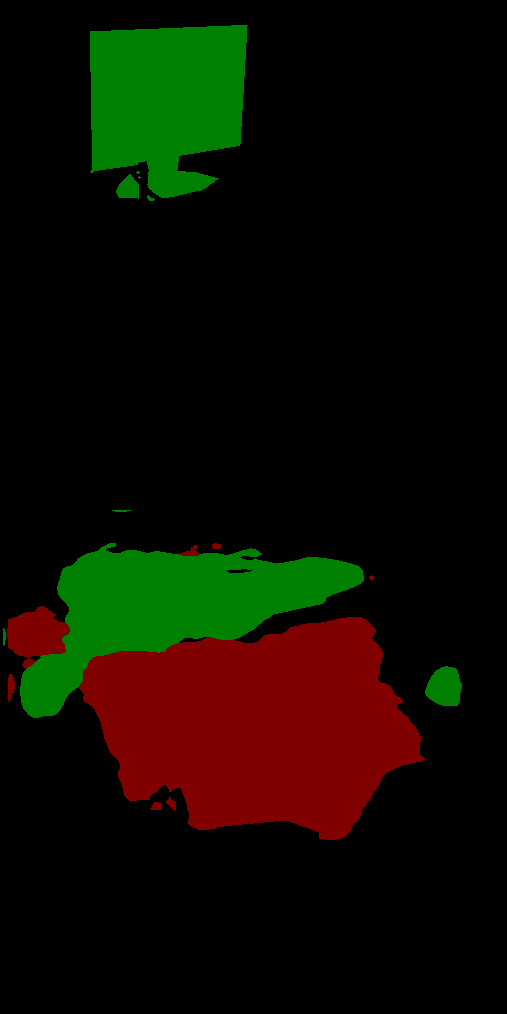

In [34]:
torch.cat([segmentation_gt, create_rgb_segmentation(results["logits"].argmax(dim=1).cpu())], dim=0).rgb

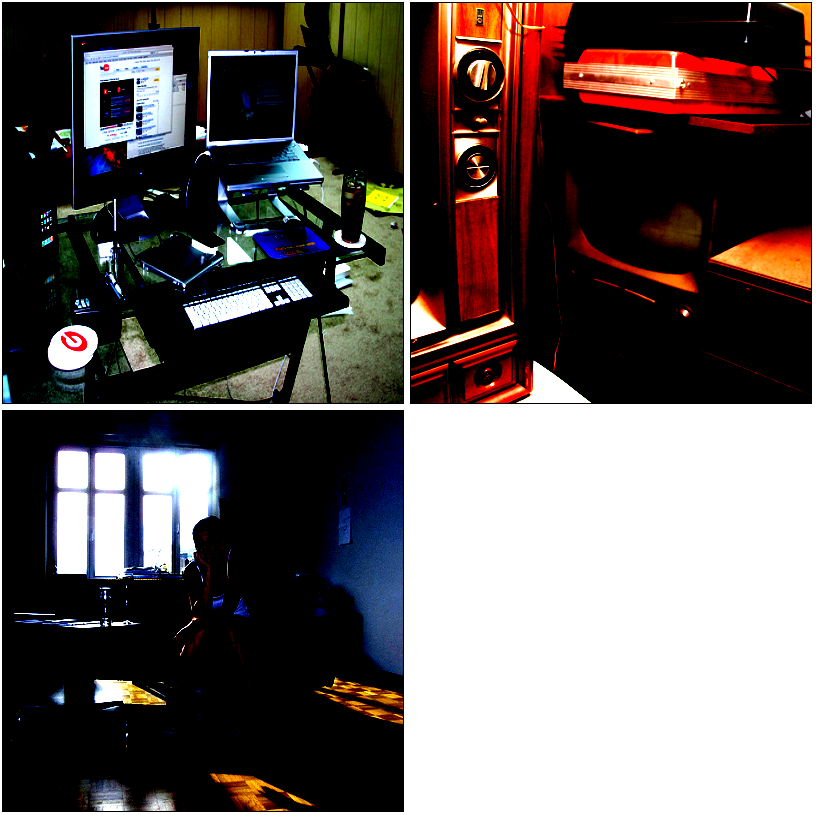

In [35]:
batch['images'][0, :].rgb